Imports

In [11]:
import os
import glob
import numpy as np
import rasterio
from rasterio.plot import show
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    f1_score,
    classification_report
)
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

processed_dir = "../data/processed/"
held_out_fire = "bootleg_fire"

feature_names = ['ndvi', 'nbr', 'esa_landcover', 'era5_mean_temp', 'chirps_precip', 'srtm_dem', 'slope', 'aspect']

Load raster as array helper function

In [12]:
def load_raster(path):
    with rasterio.open(path) as src:
        arr = src.read().astype("float32")
        profile = src.profile
    return arr, profile

Load training fires

In [13]:
train_features_list = []
train_labels_list = []

for fire_folder in os.listdir(processed_dir):
    if fire_folder == held_out_fire:
        continue
    
    feat_path = os.path.join(processed_dir, fire_folder, "features.tif")
    label_path = os.path.join(processed_dir, fire_folder, "labels.tif")

    if not os.path.exists(feat_path) or not os.path.exists(label_path):
        print(f"Skipping: {fire_folder} (missing files)")
        continue
    
    X, _ = load_raster(feat_path)
    y, _ = load_raster(label_path)

    X = X.reshape(X.shape[0], -1).T  
    y = y.reshape(-1)

    mask = (y == 0) | (y == 1)
    X = X[mask]
    y = y[mask]

    train_features_list.append(X)
    train_labels_list.append(y)

# Combine into single training set
X_train = np.vstack(train_features_list)
y_train = np.hstack(train_labels_list)

print("Training data loaded:")
print("  X_train:", X_train.shape)
print("  y_train:", y_train.shape)

Training data loaded:
  X_train: (106016, 8)
  y_train: (106016,)


Load held out fire test set

In [14]:
feat_path = os.path.join(processed_dir, held_out_fire, "features.tif")
label_path = os.path.join(processed_dir, held_out_fire, "labels.tif")

X_test, test_profile = load_raster(feat_path)
y_test, _ = load_raster(label_path)

X_test = X_test.reshape(X_test.shape[0], -1).T
y_test = y_test.reshape(-1)

mask = (y_test == 0) | (y_test == 1)
X_test = X_test[mask]
y_test = y_test[mask]

print("Held-out Bootleg fire loaded:")
print("  X_test:", X_test.shape)
print("  y_test:", y_test.shape)

Held-out Bootleg fire loaded:
  X_test: (24976, 8)
  y_test: (24976,)


Scale features for Logistic Regression

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train Models

In [22]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        tree_method="hist"
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        class_weight="balanced",
        verbose="-1"
    )
}

results = {}
predictions = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    predictions[name] = preds

    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "confusion_matrix": confusion_matrix(y_test, preds),
        "classification_report": classification_report(y_test, preds, output_dict=True),
    }
    
print("\nAll models trained.\n")


Training Logistic Regression...

Training Random Forest...


c:\Users\John Waugh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\John Waugh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\John Waugh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_


Training XGBoost...


c:\Users\John Waugh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\John Waugh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\John Waugh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_


Training LightGBM...

All models trained.



c:\Users\John Waugh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


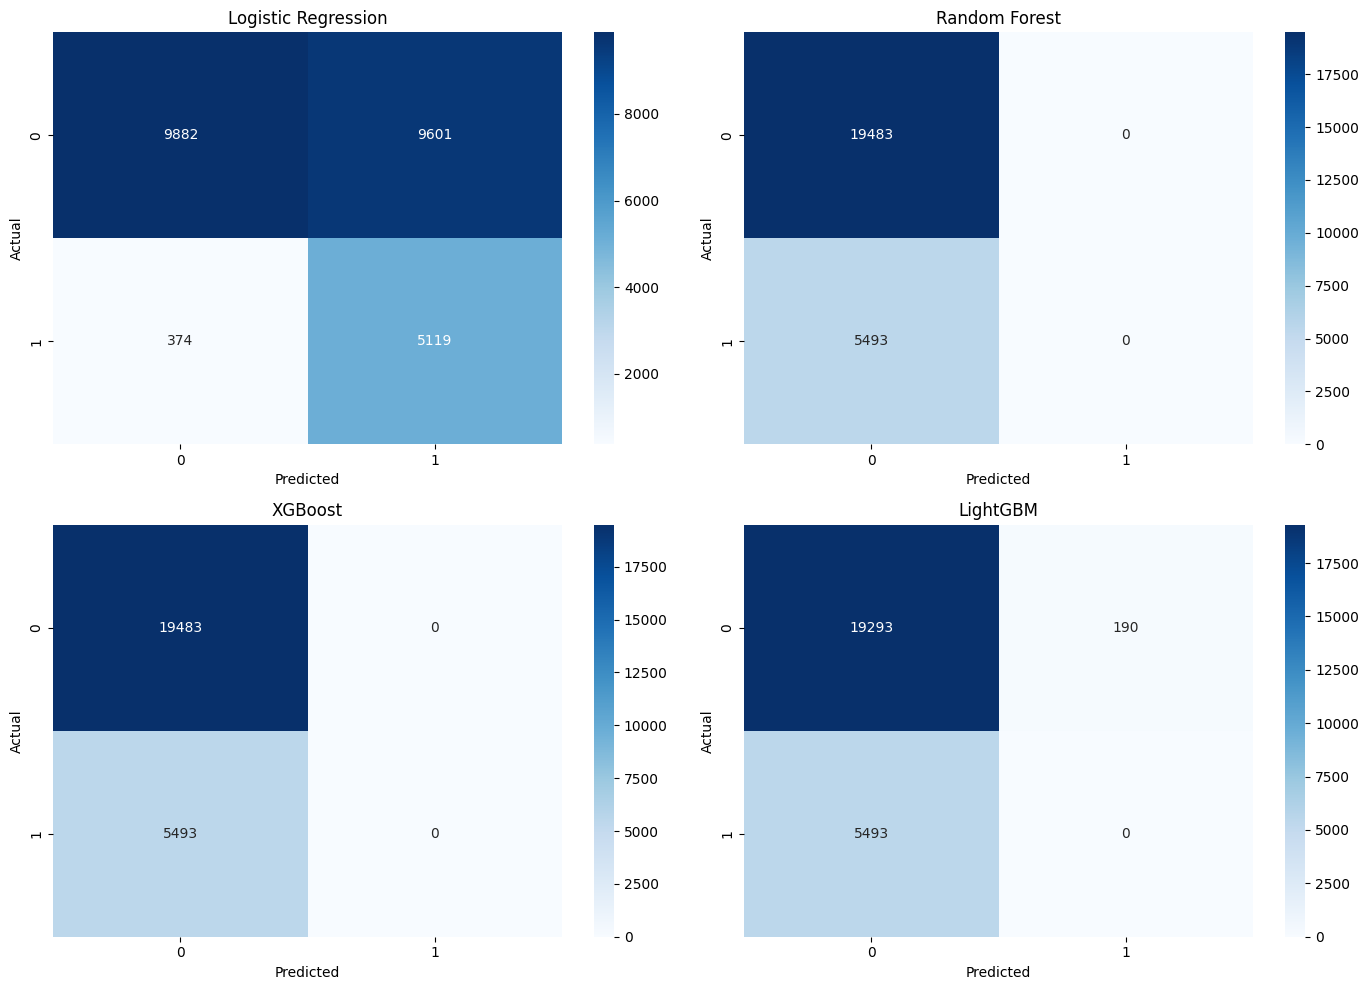

In [24]:
plt.figure(figsize=(14,10))

for i, (name, res) in enumerate(results.items(), 1):
    cm = res["confusion_matrix"]
    plt.subplot(2, 2, i)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

Feature Importance

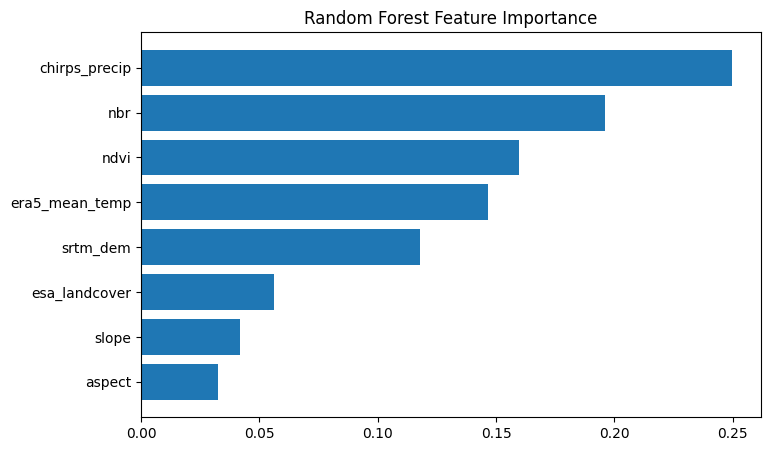

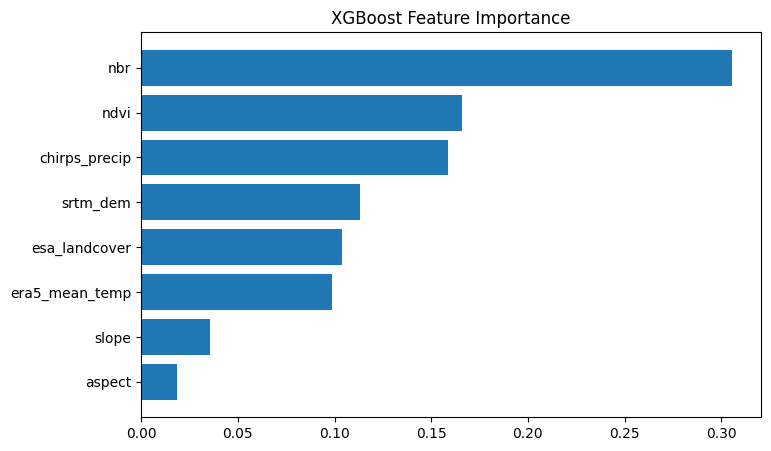

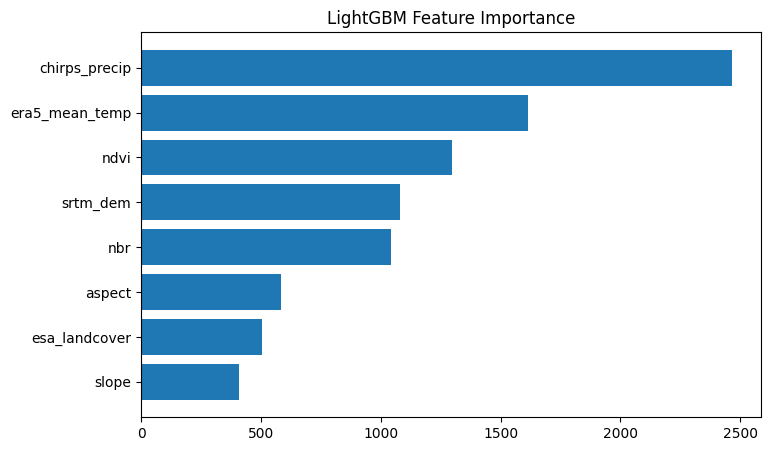

In [19]:
def plot_importances(model, name):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        idx = np.argsort(importances)[::-1]

        plt.figure(figsize=(8,5))
        plt.barh(np.array(feature_names)[idx], importances[idx])
        plt.title(f"{name} Feature Importance")
        plt.gca().invert_yaxis()
        plt.show()

plot_importances(models["Random Forest"], "Random Forest")
plot_importances(models["XGBoost"], "XGBoost")
plot_importances(models["LightGBM"], "LightGBM")


Classification Reports

In [20]:
for name, preds in predictions.items():
    print(name)
    print(classification_report(y_test, preds))

Logistic Regression
              precision    recall  f1-score   support

         0.0       0.96      0.51      0.66     19483
         1.0       0.35      0.93      0.51      5493

    accuracy                           0.60     24976
   macro avg       0.66      0.72      0.59     24976
weighted avg       0.83      0.60      0.63     24976

Random Forest
              precision    recall  f1-score   support

         0.0       0.78      1.00      0.88     19483
         1.0       0.00      0.00      0.00      5493

    accuracy                           0.78     24976
   macro avg       0.39      0.50      0.44     24976
weighted avg       0.61      0.78      0.68     24976

XGBoost
              precision    recall  f1-score   support

         0.0       0.78      1.00      0.88     19483
         1.0       0.00      0.00      0.00      5493

    accuracy                           0.78     24976
   macro avg       0.39      0.50      0.44     24976
weighted avg       0.61      0.7

c:\Users\John Waugh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\John Waugh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\John Waugh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_